# Instructions

**Please follow these instructions carefully to ensure your submission is graded correctly:**

- Fill in **your answers** in any place that says "YOUR CODE HERE" or "YOUR ANSWER HERE" in the provided `.ipynb` files.

- Do not use print statements or the variable name `_` to display your answers; instead, make sure the last line of the cell contains the variable that holds your answer.

- Your answers to code-based questions must be **generated from code**. Hardcoded answers will result in a deduction of points.  

- Do not change the **autograding cells** labelled with `"AUTOGRADING CELL - DO NOT TOUCH!"`. Modifying or deleting them may lead to incorrect grading results.

- All plots must have appropriate **axis labels** including units where applicable. Failing to do so will result in a partial deduction of points.

- Always proide **units** for quantities where applicable. Failing to do so will result in a partial deduction of points.

- The **code quality** will not be graded. However, concise, well-structured code makes it easier to awared partial points in case of errors.

- The quality of **written answers** and **figures** will be considered during grading.

- Do not use additional packages that are not part of the course **environment**. This would lead to errors during autograding.

- Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

- Submissions must be your own work, **plagiarism** from the web or peers will be checked for and sanctioned.

- Please upload only the provided `.ipynb` files, filled in with your answers.

- Please **do not** put the `.ipynb` files into archives (e.g., `.zip`, `.tar.gz`); also `.py` files will **not** be accepted. Please **do not change the file names** and do not upload additional files.

- Submission on ISIS *(for TU Berlin students)* requires **two-factor authentication**.

---

## Task 4: Investment Optimisation (26 points)

**In this task you are asked to perform some sensitivity analysis in the field of investment optimisation.**

You are provided with a simple PyPSA network (`n = pypsa.examples.model_energy()`). This network contains is for a single region with load time series, a battery, as well as wind and solar generators with capacity factor time series. It has an electricity bus and a hydrogen bus with underground storage, which are connected by an electrolyser and a hydrogen turbine. There is also a high variable cost load shedding option. The network is set up to allow for capacity expansion in all components.

More information on the network can be found in the [PyPSA documentation](https://docs.pypsa.org/latest/examples/capacity-expansion-planning-single-node/).

In [1]:
import pypsa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pypsa.options.params.optimize.solver_name = "highs"
pypsa.options.params.optimize.solver_options = {"LogToConsole": 0}

n = pypsa.examples.model_energy()

INFO:pypsa.network.io:Retrieving network data from https://github.com/PyPSA/PyPSA/raw/v1.1.2/examples/networks/model-energy/model-energy.nc.
INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Model-Energy' has buses, carriers, generators, links, loads, storage_units, stores


**a)** Calculate the annuitised capital cost (in €/MW/a) of a nuclear power plant with an overnight investment cost of 10,000 €/kW, a lifetime of 40 years and a discount rate of 7.5%. Return the result as a float. **(2 points)**

In [40]:
# YOUR CODE HERE
ann_cap_cost = (10000 * ((0.075 * (1+0.075)**40) / ((1+0.075)**40 - 1))) * 1000
ann_cap_cost


794003.1380297343

In [8]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**b)** Add the option for building a new nuclear power plant to the network named `"nuclear"`. The generator should use the capital cost calculated in (a) and a marginal cost of 20 €/MWh electricity, covering fuel and maintenance costs. Additionally, consider that the nuclear power plant is inflexible with a minimum partial load of 90%. **(2 points)**

In [16]:
# YOUR CODE HERE
n.add("Carrier", name = "nuclear", color = 'black')
n.add("Generator", "nuclear",
      bus="electricity",
      carrier = "nuclear",
      p_nom_extendable=True,
      p_min_pu=0.9,
      marginal_cost=20,
      capital_cost=ann_cap_cost,
      overwrite = True)


In [17]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [18]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [19]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [20]:
### AUTOGRADING CELL - DO NOT TOUCH!

**Now, perform a sensitivity analysis on the capital cost of the nuclear power plant. Vary the capital cost between 2,000 €/kW and 12,000 €/kW and answer the questions below.**

In [27]:
# YOUR CODE HERE

cost_results = {}
gen_share_results = {}
cost_share_results = {}

for cost_kw in range(2000, 12001, 2000):
    ann_cap_cost = cost_kw * 1000 * ((0.075 * (1+0.075)**40) / ((1+0.075)**40 - 1))
    n.add(
        "Generator", 
        "nuclear",
        bus="electricity",
        carrier="nuclear",
        p_nom_extendable=True,
        p_min_pu=0.9,
        marginal_cost=20,
        capital_cost=ann_cap_cost,
        overwrite=True
    )
    n.optimize(solver_name="highs")

    cost_results[cost_kw] = n.objective / 1e9

    total_generation = n.generators_t.p.sum().sum()
    nuclear_generation = n.generators_t.p["nuclear"].sum()
    
    gen_share_results[cost_kw] = (nuclear_generation / total_generation) * 100
    
    nuc_capex = n.generators.at["nuclear", "p_nom_opt"] * ann_cap_cost
    
    nuc_opex = nuclear_generation * n.generators.at["nuclear", "marginal_cost"]
    cost_share_results[cost_kw] = ((nuc_capex + nuc_opex) / n.objective) * 100

series_c = pd.Series(cost_results, name="total_system_cost_bln")
series_c.index.name = "overnight_cost_eur_kw"

series_d = pd.Series(gen_share_results, name="nuclear_generation_share_pct")
series_d.index.name = "overnight_cost_eur_kw"

series_e = pd.Series(cost_share_results, name="nuclear_cost_share_pct")
series_e.index.name = "overnight_cost_eur_kw"

/var/folders/1s/5g1n6w4x0ksckcmsmvfzf3zw0000gn/T/ipykernel_19905/2226284458.py:20: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="highs")
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - LogToConsole: 0
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 441.68it/s]
INFO:linopy.io: Writing time: 0.38s


ERROR:   getOptionIndex: Option "LogToConsole" is unknown
Running HiGHS 1.14.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-32237bwm has 70087 rows; 32127 cols; 138745 nonzeros
Coefficient ranges:
  Matrix  [2e-04, 3e+00]
  Cost    [6e+01, 2e+05]
  Bound   [0e+00, 0e+00]
  RHS     [5e+03, 1e+04]
Presolving model
39458 rows, 30705 cols, 106694 nonzeros 0s
33618 rows, 24865 cols, 111112 nonzeros 0s
Dependent equations search running on 5840 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
33618 rows, 24865 cols, 111112 nonzeros 0s
Presolve reductions: rows 33618(-36469); columns 24865(-7262); nonzeros 111112(-27633) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -9.9288237843e+05 Ph1: 21938(36849.2); Du: 10258(992882) 0.1s
      13210     5.2034622634e+08 Pr: 6264(2.50752e+10) 5.2s
      17410     1.796655

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 32127 primals, 70087 duals
Objective: 3.73e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.
/var/folders/1s/5g1n6w4x0ksckcmsmvfzf3zw0000gn/T/ipykernel_19905/2226284458.py:20: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False

ERROR:   getOptionIndex: Option "LogToConsole" is unknown
Running HiGHS 1.14.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-s5y791jv has 70087 rows; 32127 cols; 138745 nonzeros
Coefficient ranges:
  Matrix  [2e-04, 3e+00]
  Cost    [6e+01, 3e+05]
  Bound   [0e+00, 0e+00]
  RHS     [5e+03, 1e+04]
Presolving model
39458 rows, 30705 cols, 106694 nonzeros 0s
33618 rows, 24865 cols, 111112 nonzeros 0s
Dependent equations search running on 5840 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
33618 rows, 24865 cols, 111112 nonzeros 0s
Presolve reductions: rows 33618(-36469); columns 24865(-7262); nonzeros 111112(-27633) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -9.9288237843e+05 Ph1: 21938(36849.2); Du: 10258(992882) 0.2s
      13498     5.2039891692e+08 Pr: 6329(2.97298e+10) 5.4s
      18344     1.797156

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 32127 primals, 70087 duals
Objective: 5.02e+09
Solver model: available
Solver message: Optimal



...

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.
/var/folders/1s/5g1n6w4x0ksckcmsmvfzf3zw0000gn/T/ipykernel_19905/2226284458.py:20: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="highs")
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:So

ERROR:   getOptionIndex: Option "LogToConsole" is unknown
Running HiGHS 1.14.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-k2p0jv1y has 70087 rows; 32127 cols; 138745 nonzeros
Coefficient ranges:
  Matrix  [2e-04, 3e+00]
  Cost    [6e+01, 1e+06]
  Bound   [0e+00, 0e+00]
  RHS     [5e+03, 1e+04]
Presolving model
39458 rows, 30705 cols, 106694 nonzeros 0s
33618 rows, 24865 cols, 111112 nonzeros 0s
Dependent equations search running on 5840 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
33618 rows, 24865 cols, 111112 nonzeros 0s
Presolve reductions: rows 33618(-36469); columns 24865(-7262); nonzeros 111112(-27633) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -9.9288237843e+05 Ph1: 21938(36849.2); Du: 10258(992882) 0.1s
      13498     5.2039891692e+08 Pr: 6329(2.97298e+10) 5.3s
      18344     1.797156

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 32127 primals, 70087 duals
Objective: 8.08e+09
Solver model: available
Solver message: Optimal



      25421     8.0781356755e+09 Pr: 0(0); Du: 0(6.9395e-11) 18.4s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-k2p0jv1y
Model status        : Optimal
Simplex   iterations: 25421
Objective value     :  8.0781356755e+09
P-D objective error :  3.4236309323e-15
HiGHS run time      :         18.52


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


**c)** How do total system costs change as a function of nuclear investment costs? Provide the answer as a `pandas.Series` with the overnight investment cost (in €/kW) as the index and the total system cost (in billion € per year) as the values in order of ascending costs. **(2 points)**

In [28]:
# YOUR CODE HERE
series_c = pd.Series(cost_results, name="total_system_cost_bln")
series_c.index.name = "overnight_cost_eur_kw"
series_c
#system costs obviously increase as nuclear investment costs increase

overnight_cost_eur_kw
2000     3.727202
4000     5.019778
6000     6.199973
8000     7.282243
10000    8.071785
12000    8.078136
Name: total_system_cost_bln, dtype: float64

In [29]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

**d)** How does the contribution of nuclear power to the electricity mix change as a function of nuclear investment costs? Provide the answer as a `pandas.Series` with the overnight investment cost (in €/kW) as the index and the nuclear power contribution (in % of total electricity generated) as the values in order of ascending costs. **(2 points)**

In [41]:
# YOUR CODE HERE
series_d = pd.Series(gen_share_results, name="nuclear_generation_share_pct")
series_d.index.name = "overnight_cost_eur_kw"
series_d

overnight_cost_eur_kw
2000     99.943621
4000     90.096904
6000     83.367619
8000     75.037396
10000    16.660440
12000     0.000000
Name: nuclear_generation_share_pct, dtype: float64

In [42]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

**e)** How does the share of nuclear power in total system cost change as a function of nuclear investment costs? Provide the answer as a `pandas.Series` with the overnight investment cost (in €/kW) as the index and the nuclear power contribution (in % of total system cost) as the values in order of ascending costs. **(2 points)**

In [43]:
# YOUR CODE HERE
series_e = pd.Series(cost_share_results, name="nuclear_cost_share_pct")
series_e.index.name = "overnight_cost_eur_kw"
series_e

overnight_cost_eur_kw
2000     51.320534
4000     56.746735
6000     60.640258
8000     60.569112
10000    15.971633
12000     0.000000
Name: nuclear_cost_share_pct, dtype: float64

In [44]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

**f)** Plot the three `pandas.Series` created in parts (c), (d), and (e) in a single figure with three subplots and shared x-axis. **(2 points)**

Text(0.5, 0, 'Nuclear Investment Cost (€/kW)')

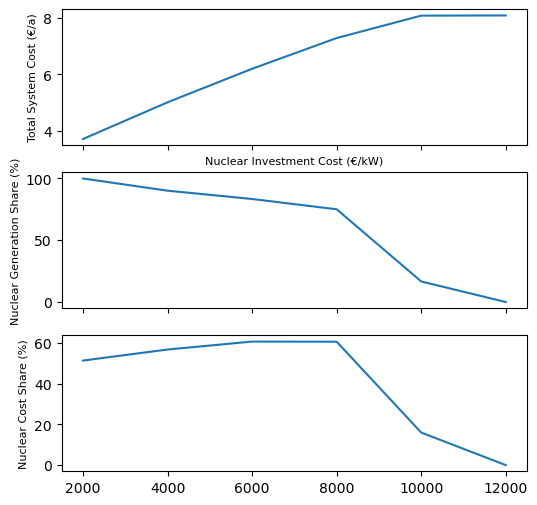

In [48]:
# YOUR CODE HERE
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(6,6))
ax1.plot(series_c)
ax2.plot(series_d)
ax3.plot(series_e)
ax1.set_ylabel("Total System Cost (€/a)", fontsize = 8)
ax2.set_ylabel("Nuclear Generation Share (%)", fontsize = 8)
ax3.set_ylabel("Nuclear Cost Share (%)", fontsize = 8)
ax1.set_xlabel("Nuclear Investment Cost (€/kW)", fontsize = 8)


**In the following, we start with a newly loaded base network without the nuclear power plant option. Now, you are asked to evaluate the potential role of a new technology in this stylised energy system: an [iron-air battery](https://formenergy.com/technology/battery-technology/).**

In [81]:
n = pypsa.examples.model_energy()
n.optimize()
base_cost = n.statistics.capex().sum() + n.statistics.opex().sum()

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Model-Energy' has buses, carriers, generators, links, loads, storage_units, stores
/var/folders/1s/5g1n6w4x0ksckcmsmvfzf3zw0000gn/T/ipykernel_19905/431519308.py:2: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - LogToConsole: 0
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 432.75it/s]
INFO:linopy.io: Writing time: 0.4s


ERROR:   getOptionIndex: Option "LogToConsole" is unknown
Running HiGHS 1.14.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-czzbp6ko has 64246 rows; 29206 cols; 124144 nonzeros
Coefficient ranges:
  Matrix  [2e-04, 3e+00]
  Cost    [1e+02, 2e+05]
  Bound   [0e+00, 0e+00]
  RHS     [5e+03, 1e+04]
Presolving model
33618 rows, 27784 cols, 92094 nonzeros 0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
30698 rows, 24864 cols, 86254 nonzeros 0s
Presolve reductions: rows 30698(-33548); columns 24864(-4342); nonzeros 86254(-37890) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 2920(1.67832e+07) 0.1s
      12835     3.1273660344e+09 Pr: 12856(4.35869e+09); Du: 0(5.58104e-08) 6.2s
      17795     8.0395477885e+09 Pr: 4908(3.82324e+08) 11.4s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 29206 primals, 64246 duals
Objective: 8.08e+09
Solver model: available
Solver message: Optimal



      18532     8.0781356755e+09 Pr: 0(0); Du: 0(3.49417e-11) 12.2s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-czzbp6ko
Model status        : Optimal
Simplex   iterations: 18532
Objective value     :  8.0781356755e+09
P-D objective error :  3.4826590519e-15
HiGHS run time      :         12.29


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


**g)** Calculate the annuitised capital cost (in €/MW/a power capacity) of the iron-air battery, assuming overnight investment cost of 20,000 €/kWh, a lifetime of 20 years, a discount rate of 7.5%, and an energy-to-power ratio of 100 hours. Return the result as a float. **(2 points)**

In [105]:
# YOUR CODE HERE
batt_ann_cost = 20000 * 100 * ((0.075 * (1+0.075)**20) / ((1+0.075)**20 - 1))
batt_ann_cost

196184.38326466287

In [106]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**h)** Add the option for building an iron-air battery as a `StorageUnit` named `"iron-air"` and optimise the network. The storage unit should use the capital cost calculated in (f), a discharge efficiency of 70%, a charging efficiency of 60%. Additionally, consider that the storage unit should be cyclic within the year. **(2 points)**

In [124]:
# YOUR CODE HERE
n.add("Carrier", "iron-air")

n.add(
    "StorageUnit",
    "iron-air",
    bus="electricity",
    carrier="iron-air", 
    max_hours=100,
    capital_cost=batt_ann_cost, 
    efficiency_store=0.6,
    efficiency_dispatch=0.7,
    p_nom_extendable=True,
    cyclic_state_of_charge=True,
)
n.optimize(solver_name="highs")
new_cost = n.statistics.capex().sum() + n.statistics.opex().sum()

/var/folders/1s/5g1n6w4x0ksckcmsmvfzf3zw0000gn/T/ipykernel_19905/1795598001.py:16: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="highs")
Index(['iron-air'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - LogToConsole: 0
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 113.12it/s]
INFO:linopy.io: Writing time: 1.32s


ERROR:   getOptionIndex: Option "LogToConsole" is unknown
Running HiGHS 1.14.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-jaa7lptj has 84687 rows; 37967 cols; 167945 nonzeros
Coefficient ranges:
  Matrix  [2e-04, 1e+02]
  Cost    [1e+02, 2e+08]
  Bound   [0e+00, 0e+00]
  RHS     [5e+03, 1e+04]
Presolving model
45298 rows, 36545 cols, 127134 nonzeros 0s
Dependent equations search running on 11680 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
42378 rows, 33625 cols, 121294 nonzeros 0s
Presolve reductions: rows 42378(-42309); columns 33625(-4342); nonzeros 121294(-46651) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 2920(2.32874e+07) 0.4s
       8658     4.2675598236e+09 Pr: 3195(4.34527e+08) 6.4s
      14402     4.2679919452e+09 Pr: 4635(2.97894e+09) 11.5s
      18996     6.6989

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 37967 primals, 84687 duals
Objective: 8.08e+09
Solver model: available
Solver message: Optimal



      23598     8.0781356755e+09 Pr: 0(0); Du: 0(9.50489e-11) 22.5s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-jaa7lptj
Model status        : Optimal
Simplex   iterations: 23598
Objective value     :  8.0781356755e+09
P-D objective error :  4.0139121276e-15
HiGHS run time      :         22.64


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


In [108]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [109]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [110]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [111]:
### AUTOGRADING CELL - DO NOT TOUCH!

**i)** By how many percent does the total system cost reduce when the iron-air battery is added? Return the result as a float (in %). **(2 points)**

In [113]:
# YOUR CODE HERE
(new_cost - base_cost)/base_cost


np.float64(0.0)

In [114]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**j)** What share of capital expenditures (in percent) is attributed to balancing technologies (i.e. everything but wind and solar generation). Return the result as a float. **(2 points)**

In [115]:
# YOUR CODE HERE
capex = n.statistics.capex().groupby(level=-1).sum()
total_capex = capex.sum()
wind_capex = capex.get("wind", 0) 
solar_capex = capex.get("solar", 0) 
balancing_capex = total_capex - wind_capex - solar_capex
balancing_capex_share = float(balancing_capex / total_capex * 100)
balancing_capex_share


41.15301890979702

In [116]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**k)** What is the optimised energy capacity of the iron-air battery (in TWh)? Return the result as a float. **(2 points)**

In [117]:
# YOUR CODE HERE
optimized_energy_capacity = n.storage_units.loc["iron-air", "p_nom_opt"] * n.storage_units.loc["iron-air", "max_hours"]
optimized_energy_capacity/1000

np.float64(-0.0)

In [118]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**l)** Plot the full-year state-of-charge profile of the iron-air battery (in TWh). **(2 points)**

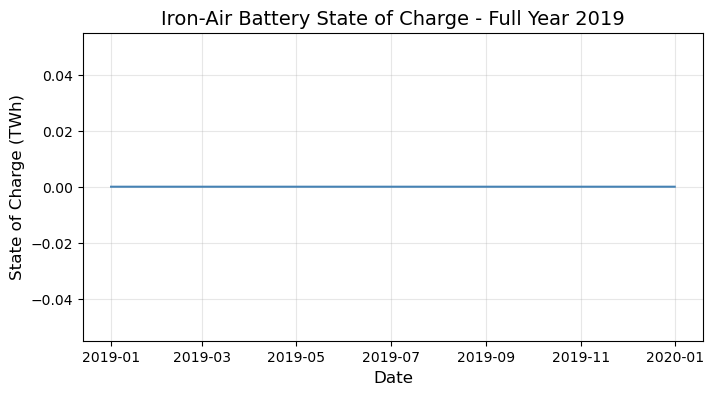

In [120]:
# YOUR CODE HERE
soc = n.storage_units_t.state_of_charge['iron-air']
soc_twh = soc / 1_000_000

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(soc_twh.index, soc_twh.values, linewidth=1.5, color='steelblue')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('State of Charge (TWh)', fontsize=12)
ax.set_title('Iron-Air Battery State of Charge - Full Year 2019', fontsize=14)
ax.grid(True, alpha=0.3)


**m)** How much energy (in TWh) is lost in the iron-air battery due to conversion inefficiencies? Return the result as a float. **(2 points)**

In [122]:
# YOUR CODE HERE
dispatch = n.storage_units_t.p['iron-air']
soc = n.storage_units_t.state_of_charge['iron-air']
energy_charged = -dispatch[dispatch < 0].sum()
energy_discharged = dispatch[dispatch > 0].sum()

efficiency_store = 0.6
efficiency_dispatch = 0.7
round_trip_efficiency = efficiency_store * efficiency_dispatch 

energy_lost = energy_charged - energy_discharged
energy_lost_twh = energy_lost / 1_000_000
energy_lost_twh


np.float64(-0.0)

In [123]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)